In [2]:
### ==========================================================
### CELL 1 — Imports
### ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score
)

from google.colab import drive
drive.mount('/content/drive')

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print('✓ Imports done')

Mounted at /content/drive
TensorFlow version: 2.19.0
GPU available: True
✓ Imports done


In [3]:
### ==========================================================
### CELL 2 — Paths (EDIT THESE TO MATCH YOUR SETUP)
### ==========================================================
BASE_DIR      = Path('/content/drive/MyDrive/IS460')
MODEL_DIR     = BASE_DIR / 'models_asvspoof2019'
DATA_DIR      = BASE_DIR / 'preprocessed_asvspoof2019'
DATA_DIR_2021 = BASE_DIR / 'preprocessed_asvspoof2021'

In [4]:
### ==========================================================
### CELL 3 — Load saved model (NO retraining)
### ==========================================================

model = tf.keras.models.load_model(MODEL_DIR / 'best_model.keras')
print('✓ Model loaded from', MODEL_DIR / 'best_model.keras')

✓ Model loaded from /content/drive/MyDrive/IS460/models_asvspoof2019/best_model.keras


In [5]:
### ==========================================================
### CELL 4 — Load preprocessed data & normalize
### ==========================================================

train_data = np.load(DATA_DIR / 'asvspoof_train.npz')
dev_data   = np.load(DATA_DIR / 'asvspoof_dev.npz')
eval_data  = np.load(DATA_DIR / 'asvspoof_eval.npz')

X_train, y_train = train_data['features'], train_data['labels']
X_dev,   y_dev   = dev_data['features'],   dev_data['labels']
X_eval,  y_eval  = eval_data['features'],  eval_data['labels']

print(f'Train : {X_train.shape} | Labels: {np.bincount(y_train)}')
print(f'Dev   : {X_dev.shape}   | Labels: {np.bincount(y_dev)}')
print(f'Eval  : {X_eval.shape}  | Labels: {np.bincount(y_eval)}')

# Add channel dim & normalize using train min/max
X_train_cnn = X_train[..., np.newaxis]
X_dev_cnn   = X_dev[..., np.newaxis]
X_eval_cnn  = X_eval[..., np.newaxis]

X_min = X_train_cnn.min()
X_max = X_train_cnn.max()

X_train_cnn = (X_train_cnn - X_min) / (X_max - X_min)
X_dev_cnn   = (X_dev_cnn   - X_min) / (X_max - X_min)
X_eval_cnn  = (X_eval_cnn  - X_min) / (X_max - X_min)

print(f'\n✓ Normalized — min: {X_min:.2f}, max: {X_max:.2f}')

Train : (25380, 128, 126) | Labels: [ 2580 22800]
Dev   : (24844, 128, 126)   | Labels: [ 2548 22296]
Eval  : (71237, 128, 126)  | Labels: [ 7355 63882]

✓ Normalized — min: -80.00, max: 0.00


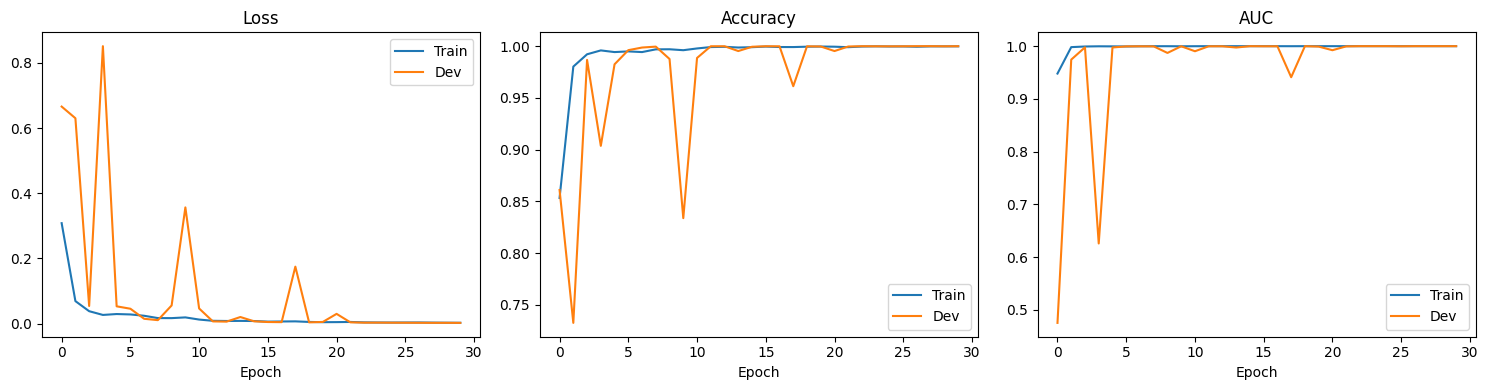

✓ Training curves plotted


In [6]:
### ==========================================================
### CELL 5 — Load training history & plot curves
### ==========================================================

with open(MODEL_DIR / 'history.json', 'r') as f:
    history = json.load(f)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['loss'],     label='Train')
axes[0].plot(history['val_loss'], label='Dev')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['accuracy'],     label='Train')
axes[1].plot(history['val_accuracy'], label='Dev')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history['auc'],     label='Train')
axes[2].plot(history['val_auc'], label='Dev')
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(MODEL_DIR / 'training_curves.png', dpi=150)
plt.show()
print('✓ Training curves plotted')

389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Best threshold : 0.40
Best macro F1  : 0.9998


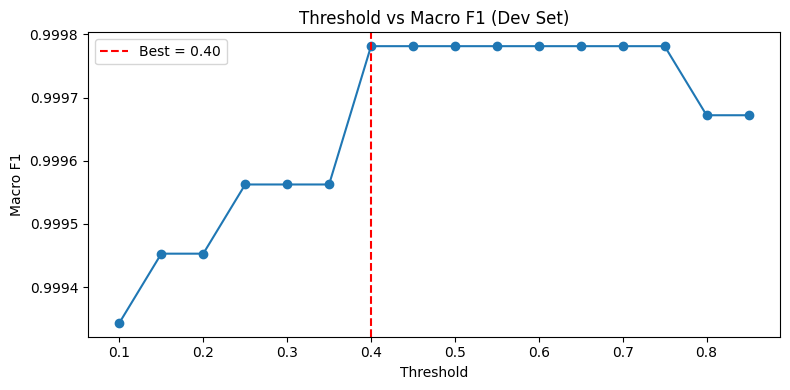

In [7]:
### ==========================================================
### CELL 6 — Threshold tuning on Dev set
### ==========================================================

y_dev_prob = model.predict(X_dev_cnn, batch_size=64).flatten()

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores  = []

for t in thresholds:
    y_pred_t = (y_dev_prob >= t).astype(int)
    f1_scores.append(f1_score(y_dev, y_pred_t, average='macro'))

best_threshold = thresholds[np.argmax(f1_scores)]
print(f'Best threshold : {best_threshold:.2f}')
print(f'Best macro F1  : {max(f1_scores):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Best = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Macro F1')
plt.title('Threshold vs Macro F1 (Dev Set)')
plt.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'threshold_tuning.png', dpi=150)
plt.show()

In [8]:
### ==========================================================
### CELL 7 — Evaluation & EER helper functions
### ==========================================================

def evaluate(model, X, y, split_name, threshold=0.5):
    y_prob = model.predict(X, batch_size=64).flatten()
    y_pred = (y_prob >= threshold).astype(int)

    print(f'\n=== {split_name} (threshold={threshold:.2f}) ===')
    print(classification_report(y, y_pred, target_names=['bonafide', 'spoof']))
    print(f'ROC-AUC: {roc_auc_score(y, y_prob):.4f}')

    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['bonafide', 'spoof'],
                yticklabels=['bonafide', 'spoof'])
    plt.title(f'Confusion Matrix — {split_name}')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(MODEL_DIR / f'cm_{split_name.replace(" ", "_").lower()}.png', dpi=150)
    plt.show()

    return y_prob, y_pred


def compute_eer(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    return ((fpr[eer_idx] + fnr[eer_idx]) / 2) * 100


print('✓ Evaluation functions ready')

✓ Evaluation functions ready


389/389 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

=== 2019 Dev (threshold=0.40) ===
              precision    recall  f1-score   support

    bonafide       1.00      1.00      1.00      2548
       spoof       1.00      1.00      1.00     22296

    accuracy                           1.00     24844
   macro avg       1.00      1.00      1.00     24844
weighted avg       1.00      1.00      1.00     24844

ROC-AUC: 1.0000


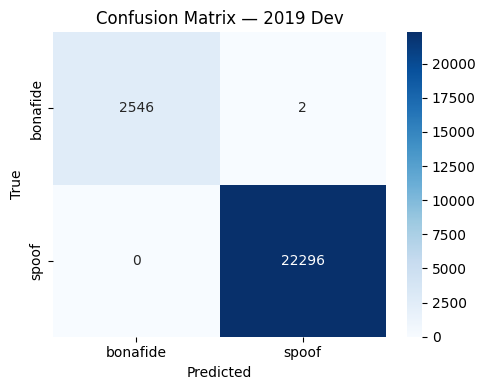

EER — 2019 Dev: 0.04%


In [9]:

### ==========================================================
### CELL 8 — Evaluate on 2019 Dev
### ==========================================================

y_dev_prob, y_dev_pred = evaluate(
    model, X_dev_cnn, y_dev,
    '2019 Dev', threshold=best_threshold
)
eer_dev = compute_eer(y_dev, y_dev_prob)
print(f'EER — 2019 Dev: {eer_dev:.2f}%')

1114/1114 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step

=== 2019 Eval (threshold=0.40) ===
              precision    recall  f1-score   support

    bonafide       0.31      1.00      0.48      7355
       spoof       1.00      0.75      0.86     63882

    accuracy                           0.78     71237
   macro avg       0.66      0.87      0.67     71237
weighted avg       0.93      0.78      0.82     71237

ROC-AUC: 0.9714


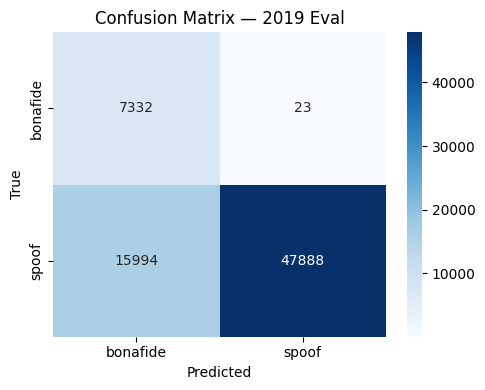

EER — 2019 Eval: 8.17%


In [10]:
### ==========================================================
### CELL 9 — Evaluate on 2019 Eval
### ==========================================================

y_eval_prob, y_eval_pred = evaluate(
    model, X_eval_cnn, y_eval,
    '2019 Eval', threshold=best_threshold
)
eer_eval = compute_eer(y_eval, y_eval_prob)
print(f'EER — 2019 Eval: {eer_eval:.2f}%')

✓ 2021 DF loaded: (152955, 128, 126, 1) | [  5535 147420]

=== 2021 DF Eval (threshold=0.40) ===
              precision    recall  f1-score   support

    bonafide       0.15      0.73      0.25      5535
       spoof       0.99      0.84      0.91    147420

    accuracy                           0.84    152955
   macro avg       0.57      0.79      0.58    152955
weighted avg       0.96      0.84      0.89    152955

ROC-AUC: 0.8783


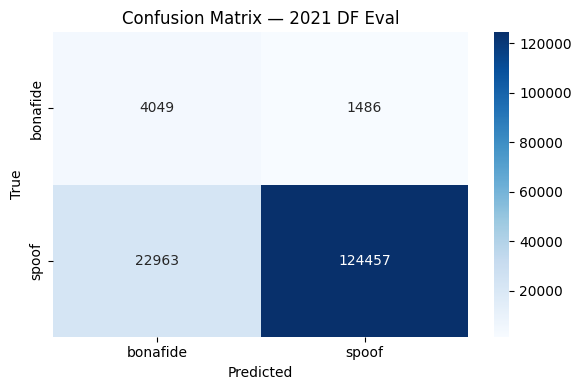

EER — 2021 DF Eval: 20.98%


In [11]:
### ==========================================================
### CELL 10 — Generalization test: 2021 DF Eval
### ==========================================================

data_2021       = np.load(DATA_DIR_2021 / 'asvspoof2021_eval.npz')
X_eval_2021     = data_2021['features']
y_eval_2021     = data_2021['labels']
files_eval_2021 = data_2021['filenames']

X_eval_2021_cnn = X_eval_2021[..., np.newaxis]
X_eval_2021_cnn = (X_eval_2021_cnn - X_min) / (X_max - X_min)
print(f'✓ 2021 DF loaded: {X_eval_2021_cnn.shape} | {np.bincount(y_eval_2021)}')


def predict_in_batches(model, X, batch_size=512):
    probs = []
    for i in range(0, len(X), batch_size):
        prob = model.predict(X[i:i+batch_size], verbose=0)
        probs.append(prob)
    return np.concatenate(probs).squeeze()


y_2021_prob = predict_in_batches(model, X_eval_2021_cnn)
y_2021_pred = (y_2021_prob >= best_threshold).astype(int)

print(f'\n=== 2021 DF Eval (threshold={best_threshold:.2f}) ===')
print(classification_report(y_eval_2021, y_2021_pred, target_names=['bonafide', 'spoof']))
print(f'ROC-AUC: {roc_auc_score(y_eval_2021, y_2021_prob):.4f}')

cm = confusion_matrix(y_eval_2021, y_2021_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['bonafide', 'spoof'],
            yticklabels=['bonafide', 'spoof'])
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix — 2021 DF Eval')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'cm_2021_df_eval.png', dpi=150)
plt.show()

eer_2021 = compute_eer(y_eval_2021, y_2021_prob)
print(f'EER — 2021 DF Eval: {eer_2021:.2f}%')

In [ ]:
### ==========================================================
### CELL 11 - CNN Performance
### ==========================================================

results = pd.DataFrame({
    'Split': ['2019 Dev', '2019 Eval', '2021 DF Eval'],
    'CNN ROC-AUC': [
        roc_auc_score(y_dev,       y_dev_prob),
        roc_auc_score(y_eval,      y_eval_prob),
        roc_auc_score(y_eval_2021, y_2021_prob)
    ],
    'CNN EER (%)': [eer_dev, eer_eval, eer_2021],
})

print('\n=== CNN ===')
print(results.to_string(index=False))



=== CNN vs AdaBoost Comparison ===
       Split  CNN ROC-AUC  CNN EER (%)  AdaBoost ROC-AUC  AdaBoost EER (%)
    2019 Dev     1.000000     0.035321            0.9260             13.93
   2019 Eval     0.971359     8.171314            0.8975             17.15
2021 DF Eval     0.878273    20.975188               NaN               NaN


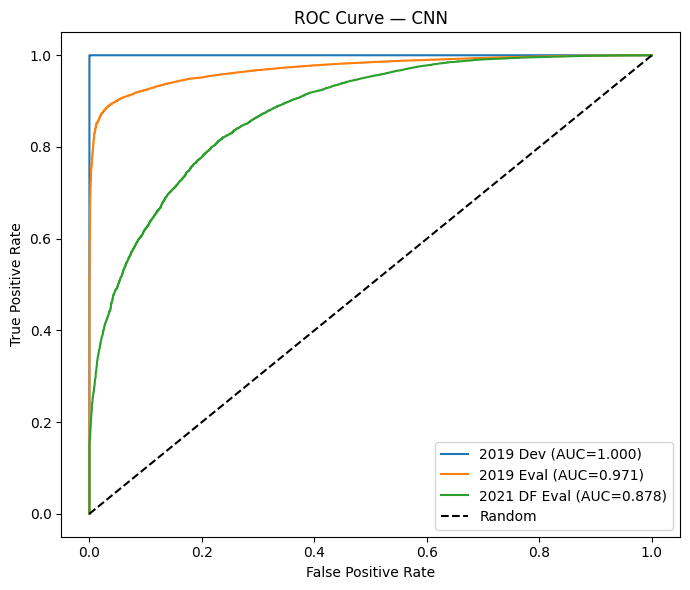

In [13]:
### ==========================================================
### CELL 12 — ROC Curves (all splits)
### ==========================================================

plt.figure(figsize=(7, 6))

for y_true, y_prob, label in [
    (y_dev,       y_dev_prob,  '2019 Dev'),
    (y_eval,      y_eval_prob, '2019 Eval'),
    (y_eval_2021, y_2021_prob, '2021 DF Eval')
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — CNN')
plt.legend()
plt.tight_layout()
plt.savefig(MODEL_DIR / 'roc_curves.png', dpi=150)
plt.show()

In [14]:
### ==========================================================
### CELL 13 — Save final artifacts
### ==========================================================

model.save(MODEL_DIR / 'cnn_audio_final.keras')
np.save(MODEL_DIR / 'cnn_threshold.npy', best_threshold)
np.save(MODEL_DIR / 'cnn_norm_params.npy', {'X_min': X_min, 'X_max': X_max})

print(f'\n✓ Model saved    : {MODEL_DIR}/cnn_audio_final.keras')
print(f'✓ Threshold saved: {best_threshold:.2f}')
print(f'✓ Norm params    : min={X_min:.2f}, max={X_max:.2f}')
print('✓ All plots saved to', MODEL_DIR)


✓ Model saved    : /content/drive/MyDrive/IS460/models_asvspoof2019/cnn_audio_final.keras
✓ Threshold saved: 0.40
✓ Norm params    : min=-80.00, max=0.00
✓ All plots saved to /content/drive/MyDrive/IS460/models_asvspoof2019
